# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [1]:
# Importing necessary libraries.
import numpy as np
import pandas as pd
import time as time
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from lightgbm import LGBMRegressor

In [2]:
# Downloading the data set.
df = pd.read_csv('datasets/taxi.csv')

In [3]:
display(df)
display(df.info())
display(df.describe())

,datetime,num_orders
0,2018-03-01 00:00:00,9
1,2018-03-01 00:10:00,14
2,2018-03-01 00:20:00,28
3,2018-03-01 00:30:00,20
4,2018-03-01 00:40:00,32
...,...,...
26491,2018-08-31 23:10:00,32
26492,2018-08-31 23:20:00,24
26493,2018-08-31 23:30:00,27
26494,2018-08-31 23:40:00,39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   datetime    26496 non-null  object
 1   num_orders  26496 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 414.1+ KB


None

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


In [4]:
# Checking for null values.
df.isnull().sum()

datetime      0
num_orders    0
dtype: int64

In [5]:
# Renaming num_orders to orders
df.rename(columns={'num_orders':'orders'}, inplace=True)

# Converting datetime to datetime.
df['datetime'] = pd.to_datetime(df['datetime'])
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26496 entries, 0 to 26495
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   datetime  26496 non-null  datetime64[ns]
 1   orders    26496 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 414.1 KB


None

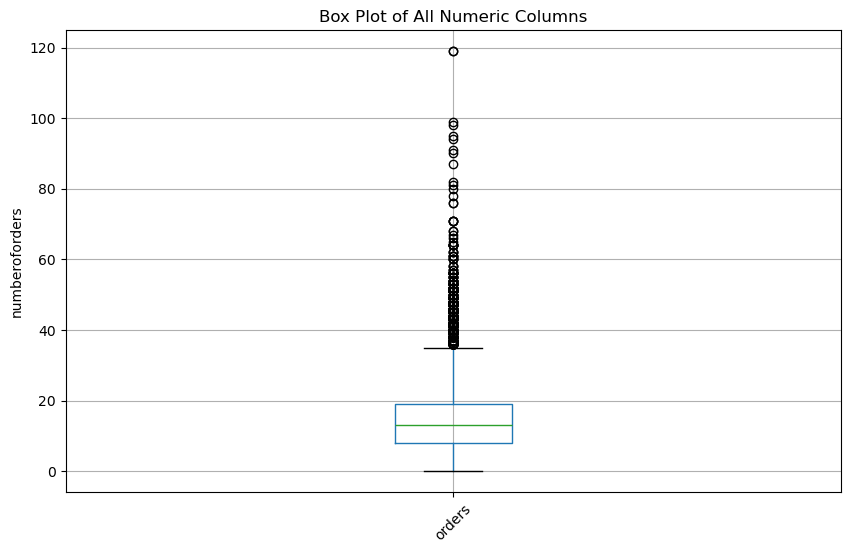

In [6]:
# Checking the data set.
# Plotting outliers
df.boxplot(figsize=(10, 6))
plt.title("Box Plot of All Numeric Columns")
plt.ylabel("numberoforders")
plt.xticks(rotation=45)
plt.show()


Although there are alot of outliers here, I'm not certain they are bad data. With out additional context I will leave as is and come back if there are issues after training and test models.

## Analysis

True


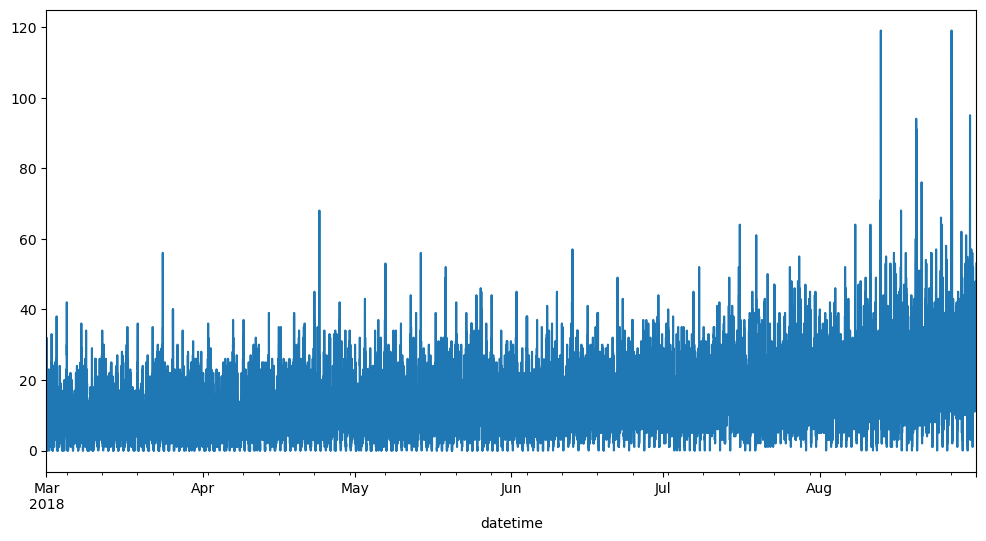

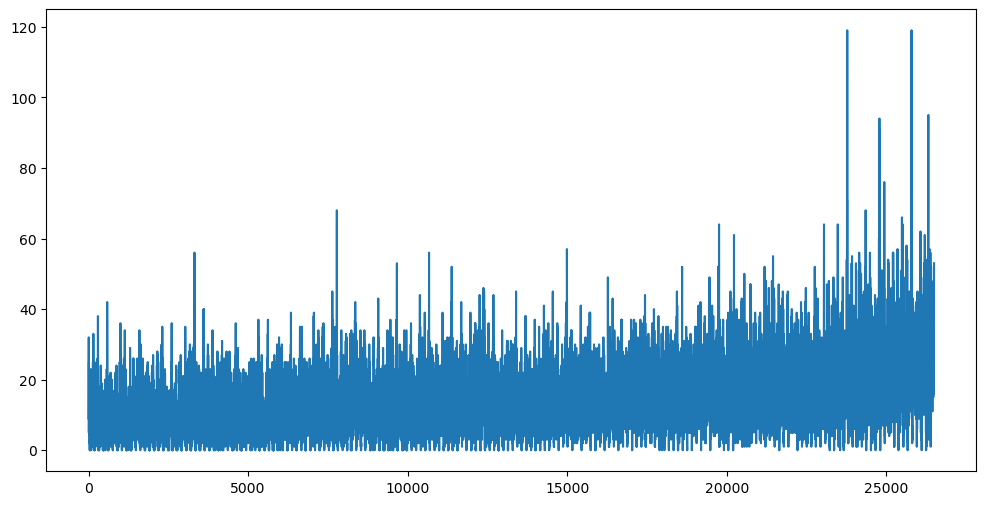

In [7]:
# Initial plotting of data
df.plot(x='datetime', y='orders', figsize = (12, 6), legend=False)
print(df.index.is_monotonic_increasing)
df.plot(y='orders', figsize=(12, 6), legend=False)
plt.show()

In [8]:
# Resampling data and getting a rolling mean.

df.set_index('datetime', inplace=True)
df_day = df.resample('1D').sum()
df_day['rolling_mean'] = df_day.rolling(10).mean()
df_day.plot()


<Axes: xlabel='datetime'>

The first graph was a raw graph which looks to be a lot of noise but you can kind of see a trend. I then resampled the data to show days along with a rolling mean and the trend line becomes more clear.

In [9]:
# Looking at the different trends.
decomposed = seasonal_decompose(df_day['orders'], model='additive')
 # < write code here >

plt.figure(figsize=(6, 8))
plt.subplot(311)
decomposed.seasonal.plot(ax=plt.gca())# To display the graph correctly, specify its
# axes ax equal to plt.gca() (gca = get current axis)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())# < write code here >
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())# < write code here >
plt.title('Residuals')

Text(0.5, 1.0, 'Residuals')

As we look at the decomposed graphs, the trend line shows a general upwards trend. The seasonality graph shows a clearer picture of a weekly cycle.

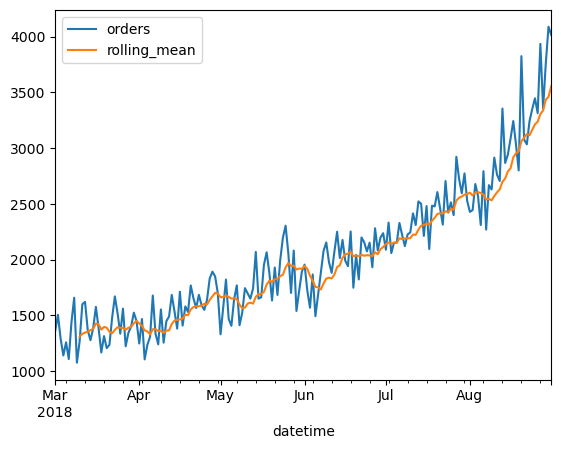

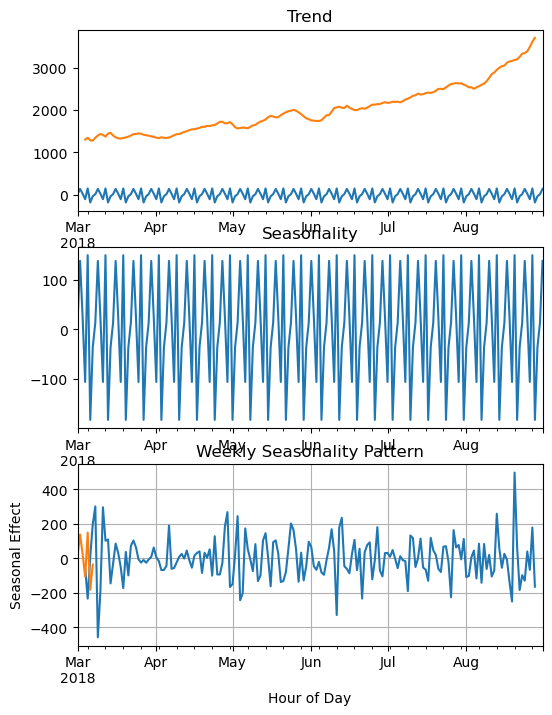

In [10]:
weekly_seasonality = decomposed.seasonal.iloc[:7]
weekly_seasonality.plot()
plt.title('Weekly Seasonality Pattern')
plt.xlabel('Hour of Day')
plt.ylabel('Seasonal Effect')
plt.grid(True)
plt.show()


March 01, 2018 was a Thursday, the pattern peaks on Friday and Monday, with the dips on Sunday and Tuesdays. I applied the ADF test on the daily-total solely as an exploratory check to gauge overall stationarity. No differencing or other transformations of the hourly series were performed based on those daily ADF results.

## Training

In [11]:
df = df.resample('1H').sum()     

In [12]:
# Function for creating addtional featrues.
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['orders'].shift(lag)

    data['rolling_mean'] = (
        data['orders'].shift().rolling(rolling_mean_size).mean()
    )

# Generating Features
make_features(df, 24, 48)
df = df.dropna()     

In [13]:
# Splitting the data set. Required is test sample is 10%
train, test = train_test_split(df, shuffle=False, test_size=0.1)
train, valid = train_test_split(train, shuffle=False, test_size=0.25)

In [14]:
# Splitting out target and features.
features_train = train.drop(columns=['orders'])
target_train = train['orders']

features_valid = valid.drop(columns=['orders'])
target_valid = valid['orders']

features_test = test.drop(columns=['orders'])
target_test = test['orders']

In [15]:
# Naive forecast: previous hour
naive_forecast = test['orders'].shift(1)

# Drop the NaN from both to keep indices aligned
mask = ~naive_forecast.isna()

rmse_naive = mean_squared_error(
    test['orders'][mask],
    naive_forecast[mask]
) ** 0.5

print(f"Naive RMSE (prev-hour): {rmse_naive:.3f}")

Naive RMSE (prev-hour): 59.083


In [16]:
# Linear regression Modeling
lr_model = LinearRegression()
lr_model.fit(features_train,target_train)
lr_pred = lr_model.predict(features_valid)
lr_rmse = np.sqrt(mean_squared_error(target_valid, lr_pred))
print(f"Linear regression RMSE on validation set: {lr_rmse:.2f}")


Linear regression RMSE on validation set: 32.33


In [17]:
# Decision tree regressor modeling.
# Gridsearch for optimal values.
dt_model = DecisionTreeRegressor(random_state=12345)
param_grid = {
    'max_depth': [3, 10, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1],
    'max_features': [None]
}
tscv = TimeSeriesSplit(n_splits=7)
grid_search = RandomizedSearchCV(estimator=dt_model, param_distributions=param_grid,
                           cv=tscv, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(features_train, target_train)

print("Best Parameters:", grid_search.best_params_)
best_dt_model = grid_search.best_estimator_

Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 3}


In [18]:
best_dt_pred = best_dt_model.predict(features_valid)
rmse = np.sqrt(mean_squared_error(target_valid, best_dt_pred))
print(f"Validation RMSE: {rmse:.4f}")

Validation RMSE: 41.5574


In [19]:
# Random forest regressor modeling.
# Gridsearch for optimal values.
rf_model = RandomForestRegressor(random_state=12345)
param_grid = {
    'n_estimators': [50,300,500],
    'max_depth': [10, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1],
    'max_features': [None]
}
tscv = TimeSeriesSplit(n_splits=7)
grid_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid,
                           cv=tscv, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(features_train, target_train)

print("Best Parameters:", grid_search.best_params_)
best_rf_model = grid_search.best_estimator_

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None}


In [20]:
best_rf_pred = best_rf_model.predict(features_valid)
rmse = np.sqrt(mean_squared_error(target_valid, best_rf_pred))
print(f"Validation RMSE: {rmse:.4f}")

Validation RMSE: 32.6957


In [21]:
#LightBGM model
lgb_model = lgb.LGBMRegressor(random_state=12345)

param_distributions = {
    'num_leaves': [40,50,70],
    'max_depth': [-1, 5, 10, 20],
    'learning_rate': [0.005, 0.01, 0.03],
    'n_estimators': [400, 500, 600],
    'min_child_samples': [1, 15, 10],
    'subsample': [0.4, 0.8, 1.0],
    'colsample_bytree': [0.4, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}
tscv = TimeSeriesSplit(n_splits=7)
random_search = RandomizedSearchCV(estimator=lgb_model,
                                   param_distributions=param_distributions,
                                   n_iter=50,
                                   cv=tscv,
                                   n_jobs=-1,
                                   scoring='neg_mean_squared_error',
                                   random_state=12345)

random_search.fit(features_train, target_train)

print("Best Parameters:", random_search.best_params_)
best_lgb_model = random_search.best_estimator_

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000251 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4255
[LightGBM] [Info] Number of data points in the train set: 2948, number of used features: 28
[LightGBM] [Info] Start training from score 70.109905
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [22]:
best_lgb_pred = best_lgb_model.predict(features_valid)
rmse = np.sqrt(mean_squared_error(target_valid, best_lgb_pred))
print(f"Validation RMSE: {rmse:.4f}")

Validation RMSE: 33.6187


I resampled the data for the modeling down to hour chunks of data. And was able to get the RMSE scores down to below 48 using linear regression, decsion tree, random forest and LightGBM. LightGBM took the longest but the time spent was negligible. Linear regression actually had the highest score. But I'm not sure, the accuracy will hold up in long run. I am going to take the LightGBM to the testing phase to see if we can achieve a model with the RMSE score of 48 or less.\

Although the linear regression model performed better than LightGBM model it has a tendency to over generalize a straight line trend. This may miss out on some of the intricacies of what is going on. Thus I chose to go with the second my accurate model LightGBM.

## Testing

In [23]:

# Recombining the training and validation data for final test.
full_train_features = pd.concat([features_train, features_valid]).sort_index()
full_train_target = pd.concat([target_train, target_valid]).sort_index()


In [24]:
#LightGBM Final testing
# Fit on the full training set
best_lgb_model.fit(full_train_features, full_train_target)

# Predict on test set
final_prediction = best_lgb_model.predict(features_test)

# Evaluate
rmse_test = np.sqrt(mean_squared_error(target_test, final_prediction))
print(f"Test RMSE: {rmse_test:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000255 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4856
[LightGBM] [Info] Number of data points in the train set: 3931, number of used features: 28
[LightGBM] [Info] Start training from score 78.589163
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [25]:
#Checking for feature importance:
importance_df = pd.DataFrame({
    'feature': best_lgb_model.feature_name_,
    'importance': best_lgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)
print(importance_df)


         feature  importance
27        lag_24         857
4          lag_1         797
5          lag_2         680
10         lag_7         653
6          lag_3         648
20        lag_17         627
26        lag_23         613
13        lag_10         606
12         lag_9         589
21        lag_18         576
11         lag_8         566
8          lag_5         550
14        lag_11         518
9          lag_6         506
15        lag_12         471
28  rolling_mean         467
19        lag_16         466
22        lag_19         465
23        lag_20         443
24        lag_21         439
17        lag_14         416
3      dayofweek         414
18        lag_15         402
25        lag_22         396
7          lag_4         391
16        lag_13         365
1          month         227
2            day         156
0           year           0


## Conclusion

It took a lot of wrangling, but I have a model with RMSE score sub 48. Here are some key takeaways from this project.

There are several seasonal patterns that exist, such as a weekly cycle and a daily cycle.
After tuning hyperparameters of the different models, I had exhausted all I could and had to go back and tune the max lag and rolling mean features in order to fine-tune performance.

I used IQR-based capping to reduce the impact of outliers. However, this technique may diminish extreme spikes in order volume—especially during busy or unusual periods such as the newest spikes on the generally upward graph.

The most important features were lag24, lag1, and lag2. This is intuitive since the same time the day before probably has the most in common with the same time today. i.e., people order things during their lunch break. Additionally, lag1 and lag2 are the previous hour and the previous hour before that. If something is being ordered hotly, it will probably stay that way in the next hour or so.
